# 30 · Opto — uniform (expert) phase

## Setup

In [1]:
%matplotlib inline
from shared_setup import *
from behav_utils.analysis.downsample import calculate_min_n, compute_ds_x
from behav_utils.analysis.stats_table import extract_stats


experiment, info = load_data()
print(f"Mode: {info['mode']}")

Loaded snapshot: 22 animals, 1267 sessions (exported 2026-07-20)
Mode: snapshot


/Users/Serkan/Desktop/pro/PhD/main/repos/sound_categorisation/notebooks/shared_setup.py:223: UserWarning: Config has changed since snapshot was exported. Re-export if column mappings changed.
  experiment, meta = load_snapshot(


## Per Animal

In [18]:
animal_id = 'SS16'
animal = experiment.get_animal(animal_id)
print(f"Animal: {animal.animal_id} ({animal.genotype.upper()})")

Animal: SS16 (HET)


### Per Phase

#### Select Session & Trials

In [ ]:
distribution = 'Uniform'
session_type = 'masking'
phase_unfiltered = select_sessions(animal, distribution=distribution, session_type=session_type)

phases = {tt: filter_trials(phase_unfiltered, trial_type=tt) for tt in ['non_opto', 'opto', 'post_opto']}


#### Compute Stats

##### Stats

In [20]:
stat_names = ['accuracy', 'recency', 'win_stay', 'lose_shift', 'side_bias', 
              'psychometric', 'psychometric_gof',
              'hard_accuracy', 'easy_accuracy']

In [21]:
stats_full = compare_phases(phases, stats=stat_names, downsample = False, 
                   n_permutations = 200, n_bootstrap = 200, 
                   reference='non_opto')

In [22]:
stats_ds = compare_phases(phases, stats=stat_names, downsample = True,
						  n_permutations = 200, n_bootstrap = 200, reference = 'non_opto')

##### Update matrices

Full

In [23]:
phase_opto_um = compute_um(phases['opto'])
phase_non_opto_um = compute_um(phases['non_opto'])
phase_post_opto_um = compute_um(phases['post_opto'])

Downsampled

In [24]:
n = calculate_min_n([phases['opto'], phases['non_opto'], phases['post_opto']], unit = 'pairs')
phase_opto_ds_um_full = compute_ds_x(phases['opto'], 'um', n, n_repeats=100)   # 100 matched draws, aggregated
phase_non_opto_ds_um_full = compute_ds_x(phases['non_opto'], 'um', n, n_repeats=100)
phase_post_opto_ds_um_full = compute_ds_x(phases['post_opto'], 'um', n, n_repeats=100)
phase_opto_ds_um = phase_opto_ds_um_full['aggregated']
phase_non_opto_ds_um = phase_non_opto_ds_um_full['aggregated']
phase_post_opto_ds_um = phase_post_opto_ds_um_full['aggregated']

#### Plot Stats

##### Psychometrics

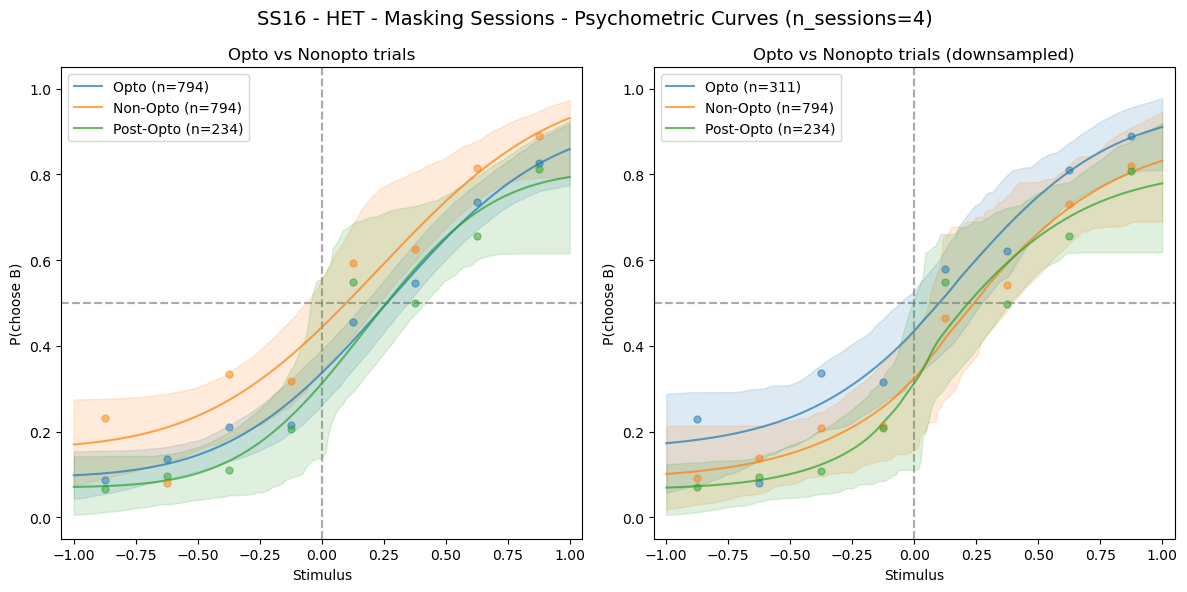

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
# Full
plot_psychometric(stats_full['phases']['non_opto']['psychometric'], title=f"Opto vs Nonopto trials ", ax = axes[0], color = PALETTE[0], 
                  label=f'Opto (n={stats_full["phases"]["non_opto"]["n_trials"]})')
plot_psychometric(stats_full['phases']['opto']['psychometric'], title=f"Opto vs Nonopto trials", ax = axes[0], color = PALETTE[1], 
                  label=f'Non-Opto (n={stats_full["phases"]["non_opto"]["n_trials"]})')
plot_psychometric(stats_full['phases']['post_opto']['psychometric'], title=f"Opto vs Nonopto trials", ax = axes[0], color = PALETTE[2], 
                  label=f'Post-Opto (n={stats_full["phases"]["post_opto"]["n_trials"]})')
axes[0].legend()

# Downsampled
plot_psychometric(stats_ds['phases']['opto']['psychometric'], title=f"Opto vs Nonopto trials (downsampled)", ax = axes[1], color = PALETTE[0], 
                  label=f'Opto (n={stats_ds["phases"]["opto"]["n_trials"]})')
plot_psychometric(stats_ds['phases']['non_opto']['psychometric'], title=f"Opto vs Nonopto trials (downsampled)", ax = axes[1], color = PALETTE[1], 
                  label=f'Non-Opto (n={stats_ds["phases"]["non_opto"]["n_trials"]})')
plot_psychometric(stats_ds['phases']['post_opto']['psychometric'], title=f"Opto vs Nonopto trials (downsampled)", ax = axes[1], color = PALETTE[2], 
                  label=f'Post-Opto (n={stats_ds["phases"]["post_opto"]["n_trials"]})')
axes[1].legend()

fig.suptitle(f"{animal.animal_id} - {animal.genotype.upper()} - {phases['non_opto'][0].session_type.capitalize()} Sessions - Psychometric Curves (n_sessions={stats_full['phases']['non_opto']['n_sessions']})", fontsize=14)
plt.tight_layout()

##### Update matrices

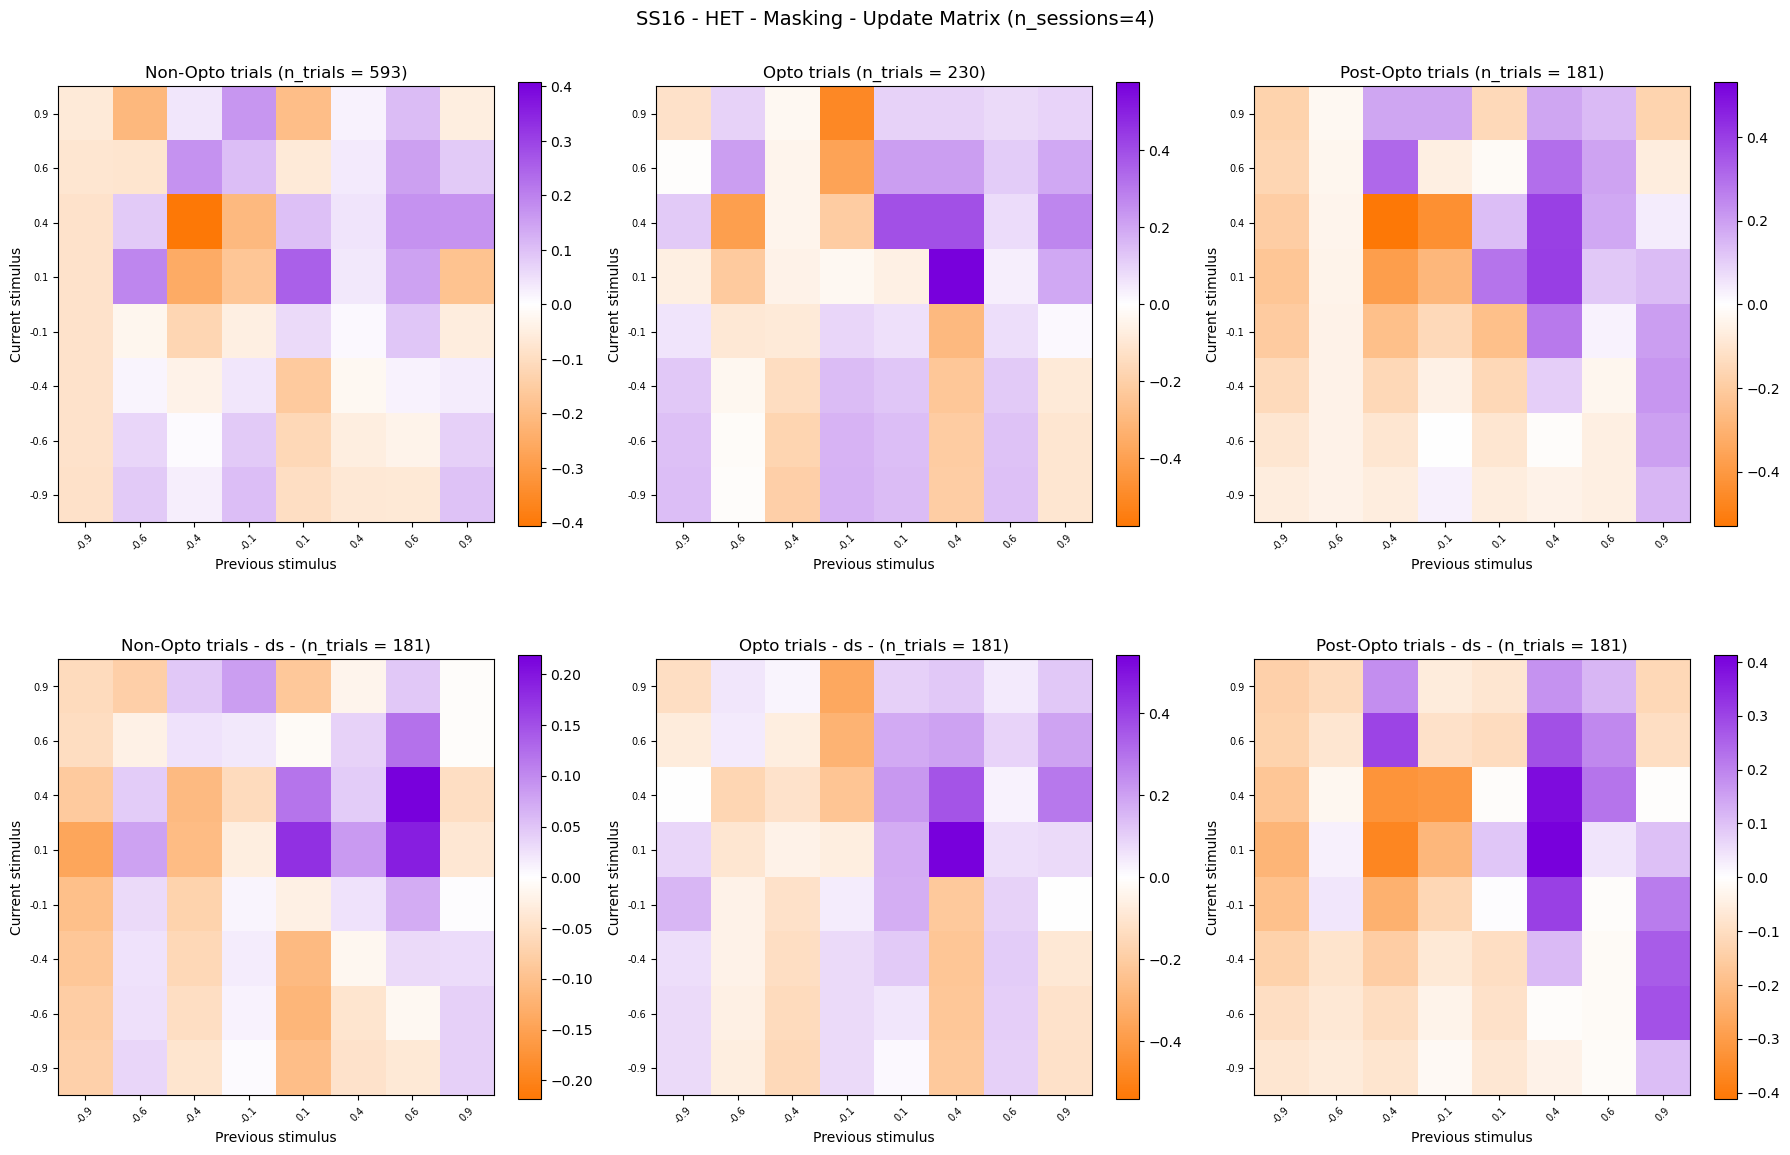

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Full
axs = axes[0]
plot_um(phase_non_opto_um, title=f"Non-Opto trials (n_trials = {phase_non_opto_um['n_trials']})", ax = axs[0])
plot_um(phase_opto_um, title=f"Opto trials (n_trials = {phase_opto_um['n_trials']})", ax = axs[1])
plot_um(phase_post_opto_um, title=f"Post-Opto trials (n_trials = {phase_post_opto_um['n_trials']})", ax = axs[2])

# Downsampled
axs = axes[1]
plot_um(phase_non_opto_ds_um, title=f"Non-Opto trials - ds - (n_trials = {phase_non_opto_ds_um['n_trials']})", ax = axs[0])
plot_um(phase_opto_ds_um, title=f"Opto trials - ds - (n_trials = {phase_opto_ds_um['n_trials']})", ax = axs[1])
plot_um(phase_post_opto_ds_um, title=f"Post-Opto trials - ds - (n_trials = {phase_post_opto_ds_um['n_trials']})", ax = axs[2])


fig.suptitle(f"{animal.animal_id} - {animal.genotype.upper()} - {phases['opto'][0].session_type.capitalize()} - Update Matrix (n_sessions={len(phases['opto'])})", fontsize=14)
plt.tight_layout()

##### Stats

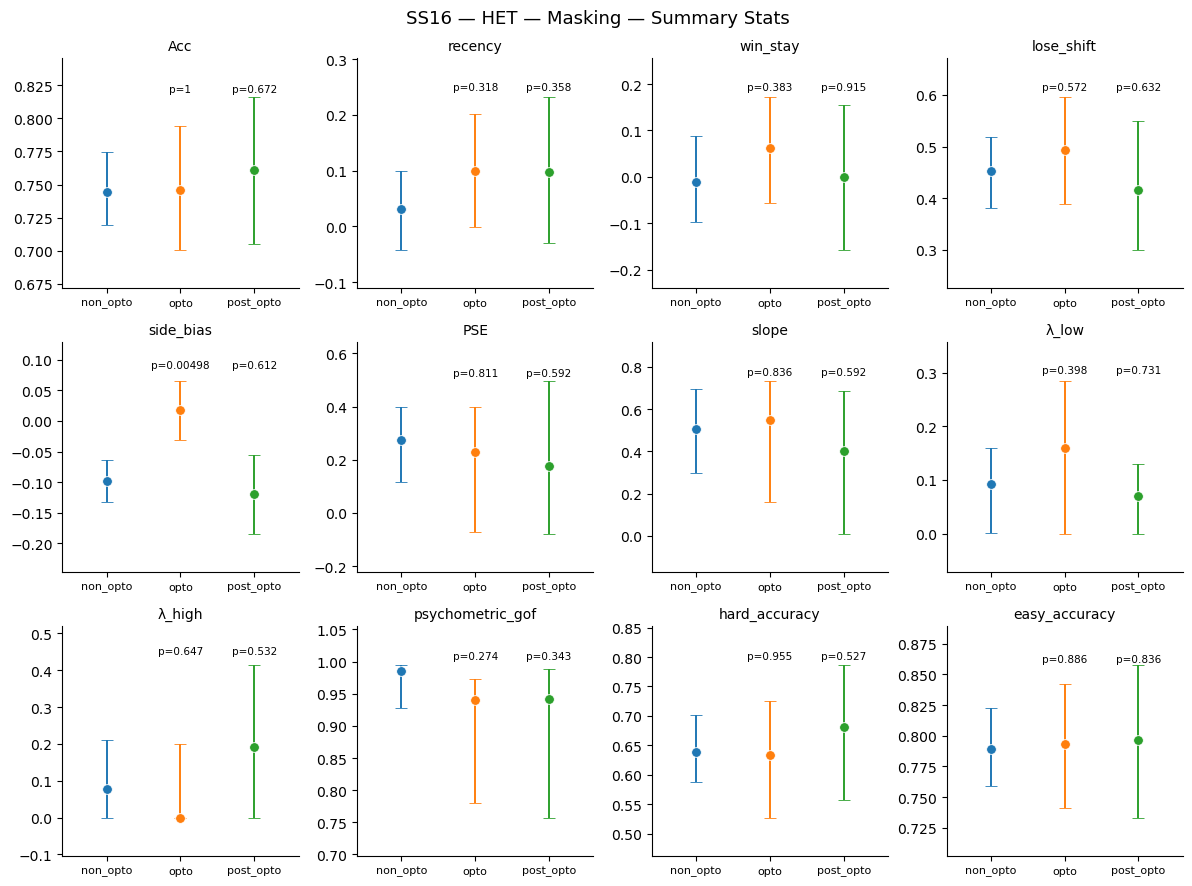

In [27]:
from behav_utils.plotting.comparison import plot_stat_comparison

fig, axes = plot_stat_comparison(stats_full, ncols=4,
    suptitle=f"{animal.animal_id} — {animal.genotype.upper()} — {phases['opto'][0].session_type.capitalize()} — Summary Stats")


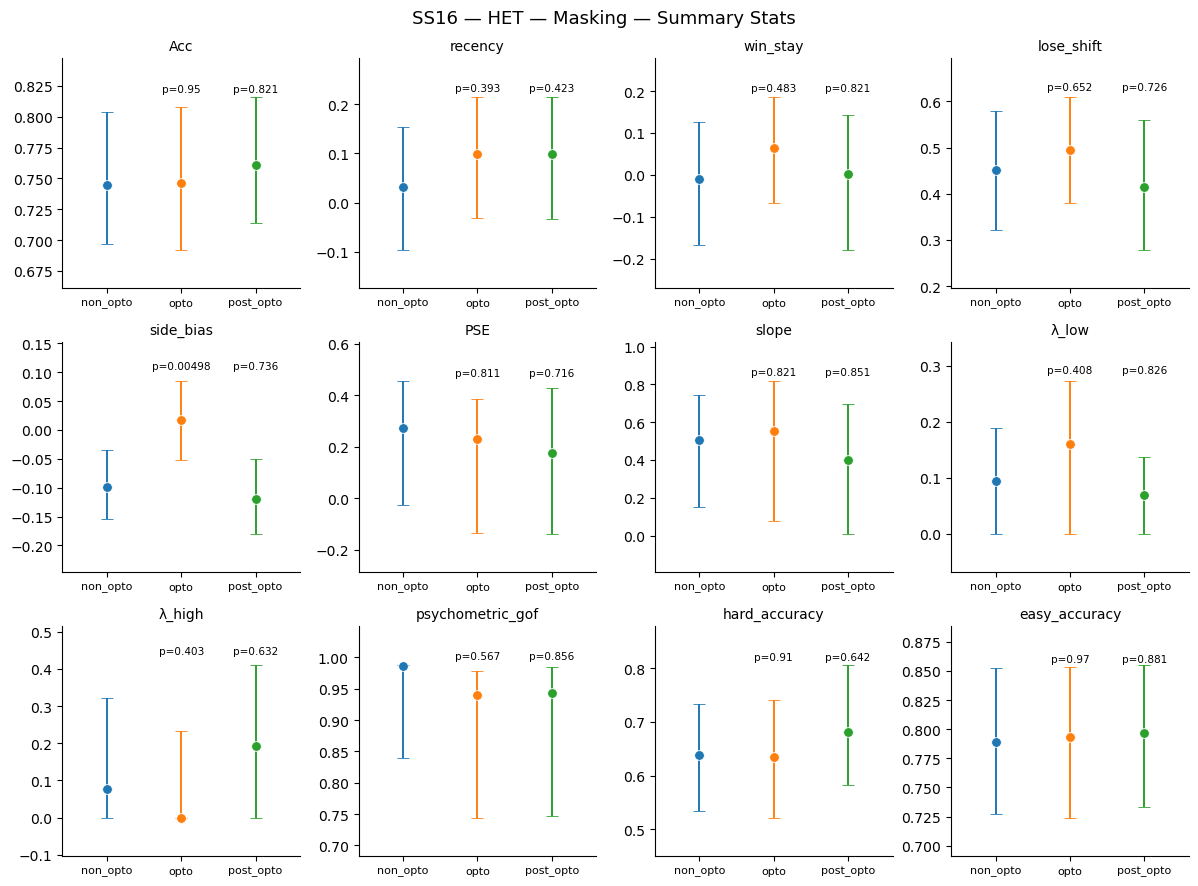

In [28]:
fig, axes = plot_stat_comparison(stats_ds, ncols=4,
    suptitle=f"{animal.animal_id} — {animal.genotype.upper()} — {phases['opto'][0].session_type.capitalize()} — Summary Stats")


### Phase Comparison

## Per Genotype